# Modern Methods of Data Analysis — Homework 2 (Part 1)

In [ ]:
import io
import os
import collections

import tqdm
import numpy
import pandas
import PIL.Image
import tqdm.contrib
import sklearn.metrics
import sklearn.cluster
import sklearn.preprocessing
import scipy.cluster.hierarchy
import matplotlib.pyplot as plt

RANDOM_STATE = 0

## Task 1 (4 points). Image clustering

In [ ]:
# First, download the data from the provided URL
! wget -O "./images.rar" "https://www.dropbox.com/scl/fi/0avngjhk7a1h5jfn073kt/images.rar?rlkey=c9xiy0yb53om8nk0nq2q23l26&dl=1"
! unar -f -o "./" "./images.rar"

--2026-05-31 19:37:57--  https://www.dropbox.com/scl/fi/0avngjhk7a1h5jfn073kt/images.rar?rlkey=c9xiy0yb53om8nk0nq2q23l26&dl=1
Resolving www.dropbox.com (www.dropbox.com)... 2620:100:6026:18::a27d:4612, 162.125.71.18
Connecting to www.dropbox.com (www.dropbox.com)|2620:100:6026:18::a27d:4612|:443... connected.
HTTP request sent, awaiting response... 302 Found
Location: https://uc21248445695a9b9931e4b80084.dl.dropboxusercontent.com/cd/0/inline/DBg26Rq16rR_Cume2wmuoNMW9RAd5w0OYTDmSEUZjtynd8ksfdkGu_mQkD-O3AEZRXfgj-y6dwSj55dzVrQQGEkfkvuxyr39Y_Vsqzh0qstkhkVFA8V_o_ADGnpEynol-Jg/file?dl=1# [following]
--2026-05-31 19:37:58--  https://uc21248445695a9b9931e4b80084.dl.dropboxusercontent.com/cd/0/inline/DBg26Rq16rR_Cume2wmuoNMW9RAd5w0OYTDmSEUZjtynd8ksfdkGu_mQkD-O3AEZRXfgj-y6dwSj55dzVrQQGEkfkvuxyr39Y_Vsqzh0qstkhkVFA8V_o_ADGnpEynol-Jg/file?dl=1
Resolving uc21248445695a9b9931e4b80084.dl.dropboxusercontent.com (uc21248445695a9b9931e4b80084.dl.dropboxusercontent.com)... 2620:100:6026:15::a27d:460f, 162

  0%|          | 0/13 [00:00<?, ?it/s]

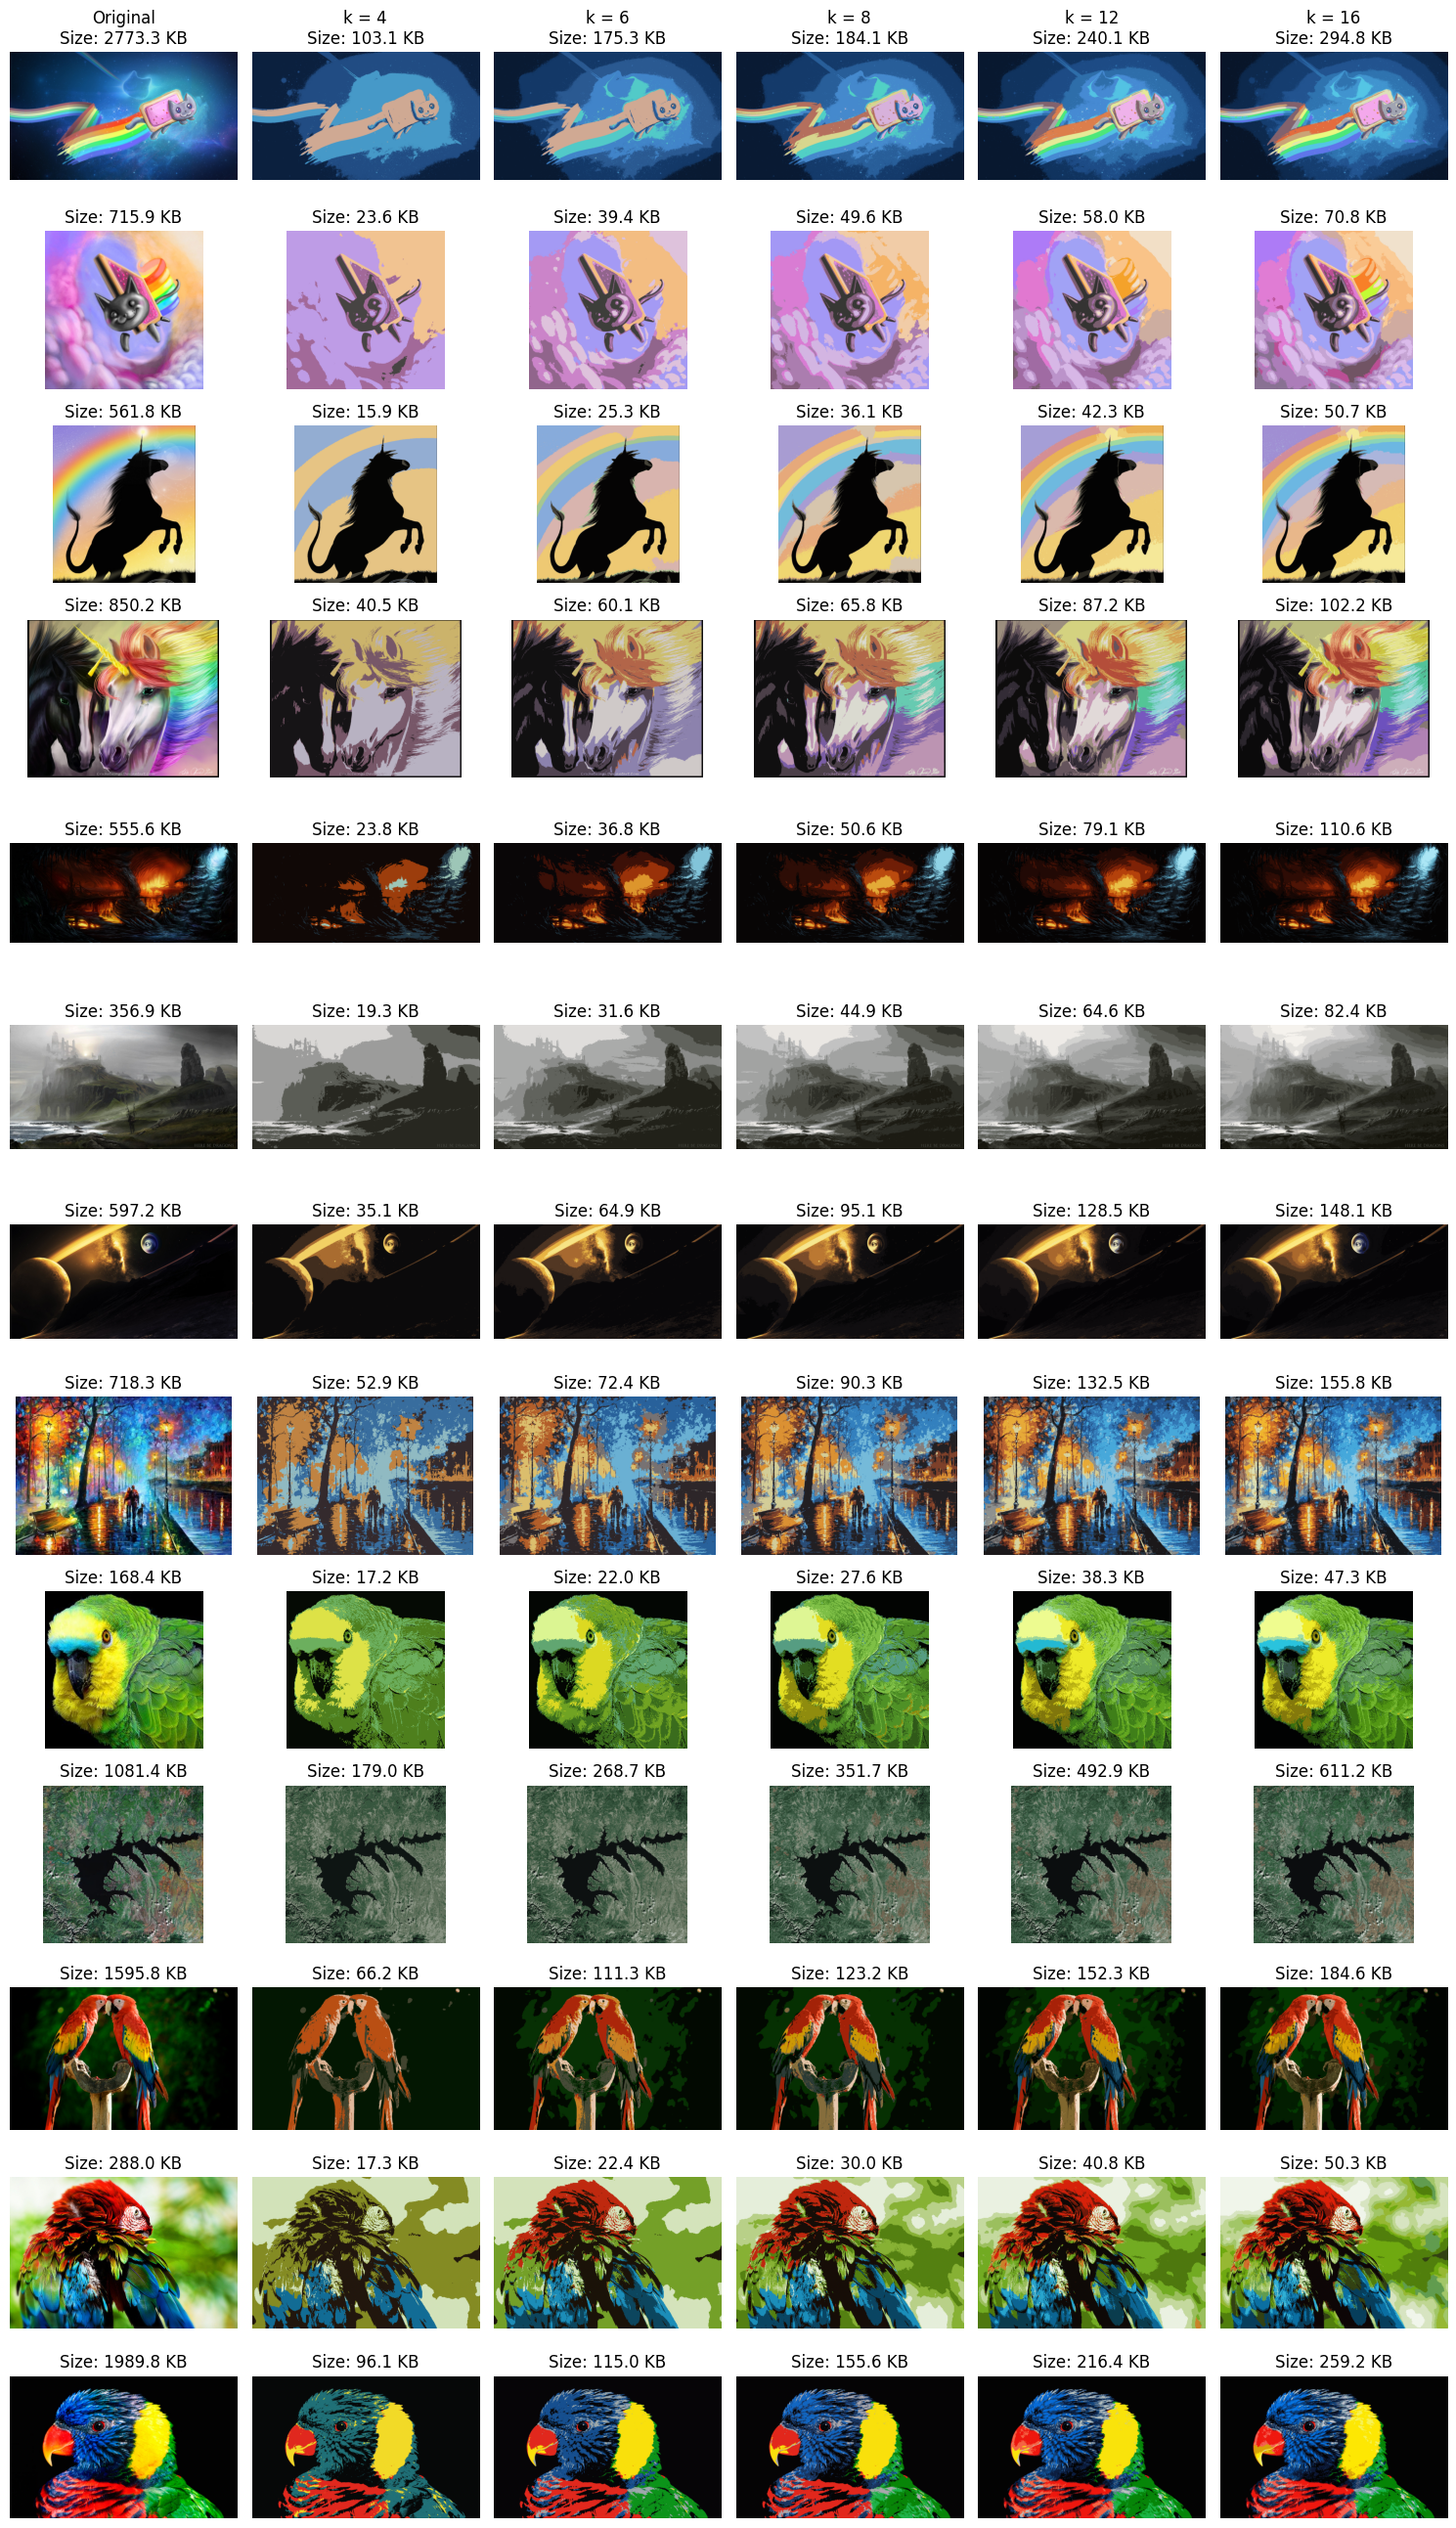

In [ ]:
def compress_image(image: numpy.ndarray, k: int):
    kmeans = sklearn.cluster.KMeans(
        n_clusters=k, random_state=RANDOM_STATE, n_init='auto'
    )
    labels = kmeans.fit_predict(image.reshape(-1, 3))
    palette = kmeans.cluster_centers_.round().astype(numpy.uint8)
    return palette[labels].reshape(*image.shape)

def setup_ax(ax, image: numpy.ndarray):
    # To measure memory, convert the image to a PNG buffer
    buf = io.BytesIO()
    PIL.Image.fromarray(image).save(buf, format='PNG', optimize=True)
    title = f"Size: {buf.tell() / 1024:.1f} KB"

    ax.imshow(image)
    ax.axis('off')
    ax.set_title(f"{ax.get_title()}\n{title}" if ax.get_title() else title)

# The task requested only one image, but why not do all, the code runs fast enough :)
# Also we will try different numbers of clusters from the given range
IMAGES, K = os.listdir("./images"), [4, 6, 8, 12, 16]
fig, axes = plt.subplots(
    len(IMAGES), len(K) + 1, squeeze=False, figsize=(2.5 * len(K) + 2.5, 2 * len(IMAGES))
)
axes[0][0].set_title("Original")
for k, ax in zip(K, axes[0][1:]):
    ax.set_title(f"k = {k}")

for image_name, axs in tqdm.contrib.tzip(IMAGES, axes):
    image = numpy.array(PIL.Image.open(f"./images/{image_name}"))
    setup_ax(axs[0], image)
    for k, ax in zip(K, axs[1:]):
        setup_ax(ax, compress_image(image, k))
fig.tight_layout()
plt.show()

The compression turns out very effective. Using `k = 16`, the size of some images was reduced by up to a factor of 8, while the recoloured image is nearly indistinguishable from the original in most cases (except for the most colorful parts like a rainbow in the nyan-cat). Moreover, even `k = 4` keeps the objects recognizable, and the results at `k = 8` would probably be indistinguishable from the original for a normal human without a direct comparison.

## Task 2 (3 points). Determine the optimal number of clusters

In [4]:
! wget -O "./elbow.txt" "https://www.dropbox.com/scl/fi/o9uf50mjx3siwxgvjfdz2/elbow.txt?rlkey=bwx5rz6kjmz4tosbuhomgj51a&e=1&dl=0"

--2026-05-31 19:38:35--  https://www.dropbox.com/scl/fi/o9uf50mjx3siwxgvjfdz2/elbow.txt?rlkey=bwx5rz6kjmz4tosbuhomgj51a&e=1&dl=0
Resolving www.dropbox.com (www.dropbox.com)... 2620:100:6026:18::a27d:4612, 162.125.71.18
Connecting to www.dropbox.com (www.dropbox.com)|2620:100:6026:18::a27d:4612|:443... connected.
HTTP request sent, awaiting response... 302 Found
Location: https://uc3b5a71ccf85086ea9700f673f2.dl.dropboxusercontent.com/cd/0/inline/DBg5ZcKKiwWZ6hLEKYiLsmLvzUgD6HFFRNgcMbdo_C-CnKavQU4pPRWOlnvZngk0kGEJwgj5h_2WX7v--8PSZ0513HRws3PZgvXfy7YRbcARiOnZ3XJU1t5SGJS25Fge2bM/file# [following]
--2026-05-31 19:38:36--  https://uc3b5a71ccf85086ea9700f673f2.dl.dropboxusercontent.com/cd/0/inline/DBg5ZcKKiwWZ6hLEKYiLsmLvzUgD6HFFRNgcMbdo_C-CnKavQU4pPRWOlnvZngk0kGEJwgj5h_2WX7v--8PSZ0513HRws3PZgvXfy7YRbcARiOnZ3XJU1t5SGJS25Fge2bM/file
Resolving uc3b5a71ccf85086ea9700f673f2.dl.dropboxusercontent.com (uc3b5a71ccf85086ea9700f673f2.dl.dropboxusercontent.com)... 2620:100:6026:15::a27d:460f, 162.125.71

(500, 2)


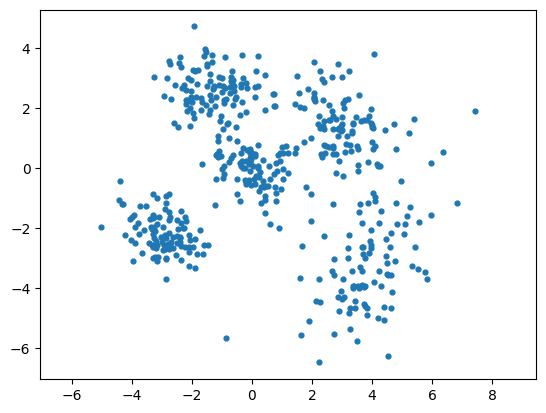

In [5]:
data = pandas.read_csv("./elbow.txt", sep='\t', header=None, decimal=",").to_numpy()
print(data.shape)
plt.scatter(data[:, 0], data[:, 1], s=12)
plt.axis("equal")
plt.show()

Solely from the scatterplot, the data looks like five separate clusters. For real data, such visual assessment is usually impossible, but in this case, 5 is probably the optimal number of clusters, which we will confirm further.

100%|██████████| 18/18 [00:00<00:00, 132.36it/s]


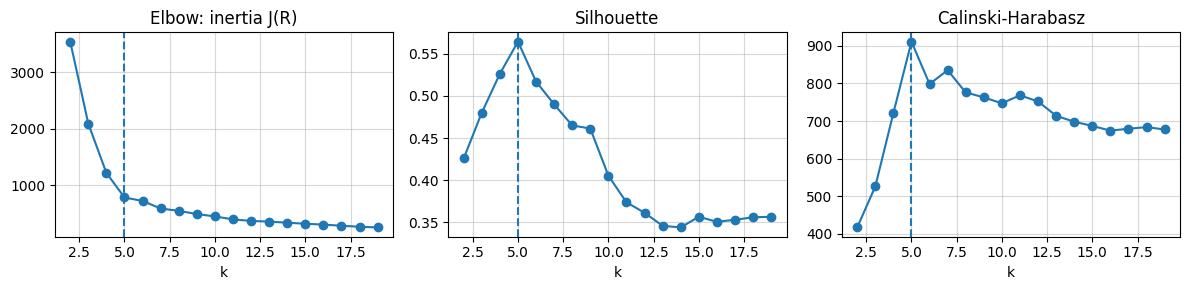

In [ ]:
ks, inertia, silh, ch = list(range(2, 20)), [], [], []
for k in tqdm.tqdm(ks):
    kmeans = sklearn.cluster.KMeans(
        n_clusters=k, random_state=RANDOM_STATE, n_init='auto'
    ).fit(data)
    # J(S) is conveniently calculated for us by sklearn as inertia
    inertia.append(kmeans.inertia_)
    # The other two are available in sklearn.metrics
    silh.append(sklearn.metrics.silhouette_score(data, kmeans.labels_))
    ch.append(sklearn.metrics.calinski_harabasz_score(data, kmeans.labels_))

fig, axes = plt.subplots(1, 3, figsize=(12, 3))
for ax in axes:
    ax.set_xlabel("k")
    ax.grid(alpha=0.5)
    ax.axvline(5, ls="--")

axes[0].plot(ks, inertia, "o-");
axes[0].set_title("Elbow: inertia J(R)")

axes[1].plot(ks, silh, "o-")
axes[1].set_title("Silhouette")

axes[2].plot(ks, ch,  "o-")
axes[2].set_title("Calinski-Harabasz")

fig.tight_layout()
plt.show()

Indeed, five is the optimal number of clusters according to all three methods:
- Inertia reaches a plateau at `k = 5`, indicating that it is an optimal value based on the elbow method
- The silhouette and Calinski-Harabasz scores reach their peaks at `k = 5`, denoting that this value achieves the most compact and well-separated clusters

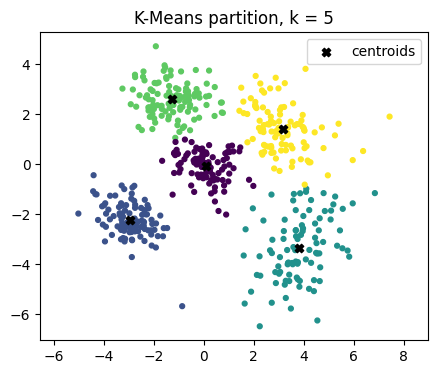

In [7]:
kmeans = sklearn.cluster.KMeans(
    n_clusters=5, random_state=RANDOM_STATE, n_init='auto'
).fit(data)

plt.figure(figsize=(5, 4))
plt.scatter(data[:, 0], data[:, 1], c=kmeans.labels_, s=12)
plt.scatter(*kmeans.cluster_centers_.T, c="black", marker="X", label="centroids")
plt.title(f"K-Means partition, k = 5")
plt.legend()
plt.axis("equal")
plt.show()

The centers of those 5 clusters look reasonable and partition the feature space relatively well, as we have observed in the original scatterplot. This confirms the result that 5 is the optimal number of clusters in KMeans for this data.

## Task 3 (3 points). Hierarchical clustering

In [8]:
! wget -O "./nutrient.dat" "https://www.dropbox.com/scl/fi/cx5i6jzlqy5ho3busmenz/nutrient.dat?rlkey=3mhxhwy150cir02fy1sg5btxt&e=1&dl=0"

--2026-05-31 19:38:38--  https://www.dropbox.com/scl/fi/cx5i6jzlqy5ho3busmenz/nutrient.dat?rlkey=3mhxhwy150cir02fy1sg5btxt&e=1&dl=0
Resolving www.dropbox.com (www.dropbox.com)... 2620:100:6026:18::a27d:4612, 162.125.69.18
Connecting to www.dropbox.com (www.dropbox.com)|2620:100:6026:18::a27d:4612|:443... connected.
HTTP request sent, awaiting response... 302 Found
Location: https://ucd2e3795ee7a8ddf867d5391da2.dl.dropboxusercontent.com/cd/0/inline/DBhiQp99XXSFRvOttNypNlcrF9yeZIMMO6JC-lB-BDZ9wjMIvxaZKTPQVr_ZhVHFrnaCz70gduG_9Yk980B5HGSFgAHWVIttsBVBmf_F70YqEA_6egZDzQ66_SwwfY0zZG8/file# [following]
--2026-05-31 19:38:39--  https://ucd2e3795ee7a8ddf867d5391da2.dl.dropboxusercontent.com/cd/0/inline/DBhiQp99XXSFRvOttNypNlcrF9yeZIMMO6JC-lB-BDZ9wjMIvxaZKTPQVr_ZhVHFrnaCz70gduG_9Yk980B5HGSFgAHWVIttsBVBmf_F70YqEA_6egZDzQ66_SwwfY0zZG8/file
Resolving ucd2e3795ee7a8ddf867d5391da2.dl.dropboxusercontent.com (ucd2e3795ee7a8ddf867d5391da2.dl.dropboxusercontent.com)... 2620:100:6026:15::a27d:460f, 162.125

In [9]:
data = pandas.read_fwf(
    "./nutrient.dat",
    encoding="utf-8-sig",
    widths=[23, 5, 5, 5, 6, 5],
    names=["name", "energy", "protein", "fat", "calcium", "iron"],
).set_index("name")
data.head()

,energy,protein,fat,calcium,iron
name,,,,,
BEEF BRAISED,340,20,28,9,2.6
HAMBURGER,245,21,17,9,2.7
BEEF ROAST,420,15,39,7,2.0
BEEF STEAK,375,19,32,9,2.6
BEEF CANNED,180,22,10,17,3.7


The five features clearly have different scales, which will break clusterization: the smaller features will probably be ignored. For reasonable results, I suggest z-scoring all features.

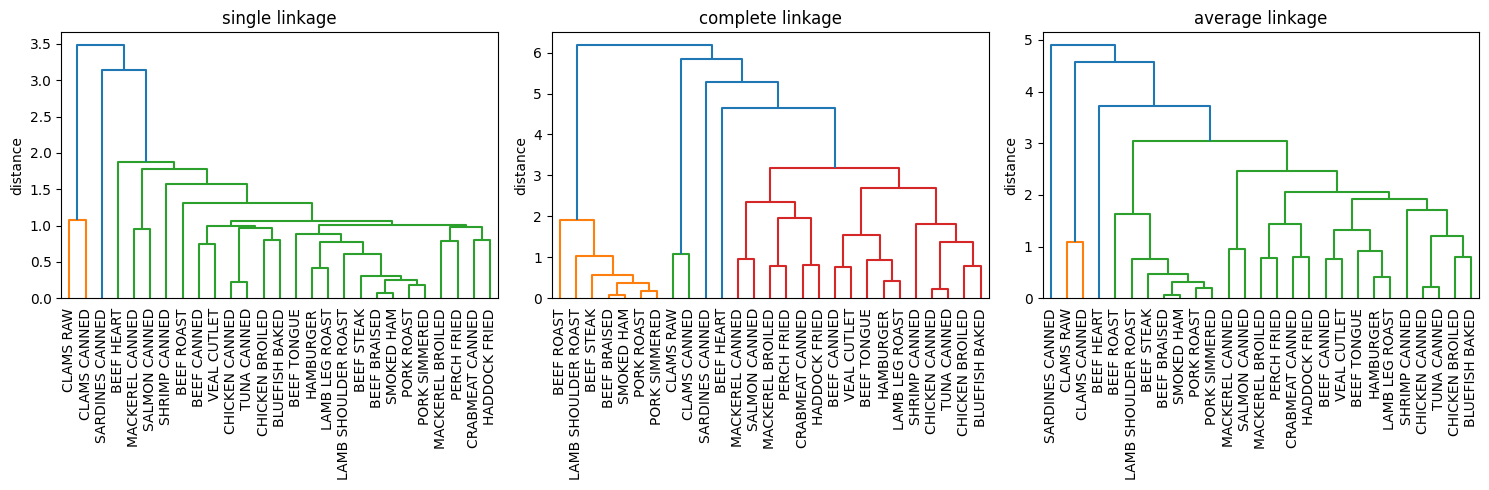

In [ ]:
X = sklearn.preprocessing.StandardScaler().fit_transform(data)

fig, axes = plt.subplots(1, 3, figsize=(15, 5))
for ax, method in zip(axes, ["single", "complete", "average"]):
    # Perform the agglomerative clustering
    linkage = scipy.cluster.hierarchy.linkage(X, method=method)
    # Construct and show the dendrogram
    scipy.cluster.hierarchy.dendrogram(
        linkage, labels=data.index, leaf_rotation=90, ax=ax
    )
    ax.set_title(f"{method} linkage")
    ax.set_ylabel("distance")
fig.tight_layout()

The best type of clustering is arguably the complete linkage. It produces meaningful clusters and has a clear gap in the merging process around the inter-cluster distance of 3-4, which denotes an optimal threshold for the final clustering (there is a big gap between clusters at that point in the process).

In the single linkage scenario, the closest pair of points in two clusters decides the merge (unlike complete linkage, where those are the furthest objects), which leads to a chaining effect: the objects are mostly added to a single cluster one-by-one.

Average linkage might be a good balanced choice, yet chaining still takes place, and there is no clear threshold to stop the process. Thus, I lean towards complete linkage for the final result.

In [11]:
linkage = scipy.cluster.hierarchy.linkage(X, method="complete")
labels = scipy.cluster.hierarchy.fcluster(linkage, t=4, criterion="distance")

print("Clusters:", collections.Counter(labels))
for c in sorted(set(labels)):
    print(f"Cluster {c}: {','.join(data.index[labels == c])}")
data.assign(cluster=labels).groupby("cluster").mean().round(1)

Clusters: Counter({3: 16, 1: 7, 2: 2, 4: 1, 5: 1})
Cluster 1: BEEF BRAISED,BEEF ROAST,BEEF STEAK,LAMB SHOULDER ROAST,SMOKED HAM,PORK ROAST,PORK SIMMERED
Cluster 2: CLAMS RAW,CLAMS CANNED
Cluster 3: HAMBURGER,BEEF CANNED,CHICKEN BROILED,CHICKEN CANNED,LAMB LEG ROAST,BEEF TONGUE,VEAL CUTLET,BLUEFISH BAKED,CRABMEAT CANNED,HADDOCK FRIED,MACKEREL BROILED,MACKEREL CANNED,PERCH FRIED,SALMON CANNED,TUNA CANNED,SHRIMP CANNED
Cluster 4: BEEF HEART
Cluster 5: SARDINES CANNED


,energy,protein,fat,calcium,iron
cluster,,,,,
1,352.9,18.6,30.1,8.7,2.4
2,57.5,9.0,1.0,78.0,5.7
3,167.2,19.8,8.6,36.8,1.7
4,160.0,26.0,5.0,14.0,5.9
5,180.0,22.0,9.0,367.0,2.5


With a threshold put inside the mentioned gap, we get three clear clusters:
- High-fat and high-energy meat: beef, pork, ham
- Clams, which are very low on energy, protein, and fat but high on calcium and iron.
- The overwhelming cluster of moderate food: poultry, fish, hamburger.

And two outliers:
- Beef heart, which is high on energy, protein, and iron but low on calcium and fat.
- Canned sardines, which are outstandingly high on calcium.

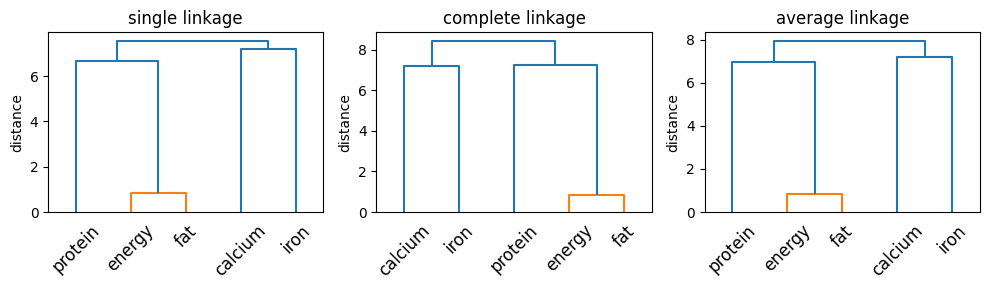

In [12]:
fig, axes = plt.subplots(1, 3, figsize=(10, 3))
for ax, method in zip(axes, ["single", "complete", "average"]):
    linkage = scipy.cluster.hierarchy.linkage(X.T, method=method)
    scipy.cluster.hierarchy.dendrogram(
        linkage, labels=data.columns, leaf_rotation=45, ax=ax
    )
    ax.set_title(f"{method} linkage")
    ax.set_ylabel("distance")
fig.tight_layout()

In [14]:
data.corr()

,energy,protein,fat,calcium,iron
energy,1.000000,0.173848,0.987067,-0.320384,-0.095389
protein,0.173848,1.000000,0.024912,-0.085089,-0.174571
fat,0.987067,0.024912,1.000000,-0.308132,-0.056253
calcium,-0.320384,-0.085089,-0.308132,1.000000,0.043099
iron,-0.095389,-0.174571,-0.056253,0.043099,1.000000


For the features, only one clear pattern stands: energy and fat are very close, and quickly merge into one cluster. Indeed, those features have a huge correlation of 0.987, indicating they are mostly duplicate. For the foods presented in the dataset, the calorie content is mostly driven by fat. The remaining features exhibit low correlations and merge only in the very end of the procedure.